<a href="https://colab.research.google.com/github/yaelezra/ReportAgent/blob/main/ReportAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install smolagents huggingface_hub

In [2]:
!pip install sentence-transformers

In [3]:
import scipy.io as sio
import pandas as pd
from google.colab import userdata
from smolagents import tool, CodeAgent, InferenceClientModel
import numpy as np
from google.colab import output

In [4]:
@tool
def load_mat_file(file_path: str) -> np.array:
    """
    Loads a self-documenting MATLAB sequence file.
    Returns np array of the sequence data.

    Args:
      file_path: The string path to your .mat file.
    """
    # 1. Load the file cleanly using our magic arguments
    mat_contents = sio.loadmat(file_path, struct_as_record=False, squeeze_me=True)

    # 2. Extract the main struct and the parameter values
    seq = mat_contents['sequence_data']

    return seq

In [5]:
@tool
def load_ultrasound_sequence(file_path: str, param_name: str) -> np.array:
    """
    Loads a self-documenting MATLAB sequence file.
    Returns the sequence data for a specific parameter (param_name).

    Args:
      file_path: The string path to your .mat file.
      param_name: The name of the parameter you want to extract.
    """
    # 1. Load the file cleanly using our magic arguments
    mat_contents = sio.loadmat(file_path, struct_as_record=False, squeeze_me=True)

    # 2. Extract the main struct and the parameter values
    seq = mat_contents['sequence_data']
    seq_param = getattr(seq, param_name)

    return seq_param

In [6]:
@tool
def load_ultrasound_doc(file_path: str) -> dict:
      """
      Loads a self-documenting MATLAB sequence file.
      Returns the documentation of all parameters.

      Args:
        file_path: The string path to your .mat file (e.g., 'ultrasound_data.mat').
      """
      # 1. Load the file cleanly using our magic arguments
      mat_contents = sio.loadmat(file_path, struct_as_record=False, squeeze_me=True)

      # 2. Extract the main struct
      seq = mat_contents['sequence_data']

      # 3. Parse the documentation into a readable string
      doc_header = f"--- Documentation for {file_path} ---\n"
      doc_entries = {}

      for field in seq.documentation._fieldnames:
          description = getattr(seq.documentation, field)
          doc_entries[field] = description

      return doc_entries

In [7]:
from sentence_transformers import SentenceTransformer, util
embedder = SentenceTransformer('all-MiniLM-L6-v2')

@tool
def find_feature_by_description(file_path: str, query: str, top_k: int = 3) -> dict:
    """
    Finds the most semantically similar features to the query using embedding similarity.
    Use this when the user asks for a feature by a loose or natural language name.
    Returns the top matching field names, their descriptions, and similarity scores.

    Args:
      file_path: The string path to your .mat file.
      query: A natural language description of the feature you're looking for.
      top_k: Number of top matches to return (default 3).
    """
    mat_contents = sio.loadmat(file_path, struct_as_record=False, squeeze_me=True)
    seq = mat_contents['sequence_data']

    # Build corpus: "field_name: description"
    fields, corpus = [], []
    for field in seq._fieldnames:
        if field == 'documentation':
            continue
        description = ''
        if field in seq.documentation._fieldnames:
            description = str(getattr(seq.documentation, field))
        fields.append(field)
        corpus.append(f"{field}: {description}")

    query_emb  = embedder.encode(query, convert_to_tensor=True)
    corpus_embs = embedder.encode(corpus, convert_to_tensor=True)

    scores = util.cos_sim(query_emb, corpus_embs)[0]
    top = scores.topk(min(top_k, len(fields)))

    results = {}
    for score, idx in zip(top.values, top.indices):
        field = fields[idx]
        results[field] = {
            "description": corpus[idx],
            "similarity":  round(float(score), 3)
        }

    return results

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
@tool
def find_feature_in_files(file_paths: list, param_name: str) -> list:
  """
  Find the same feature value in different files.

  Args:
    file_paths: TThe list of the mat files.
    param_name: The name of the parameter you want to extract.
  """
  file_features = []
  for path in file_paths:
    seq = load_mat_file(path)
    file_features.append(getattr(seq, param_name).to_list())
  return file_features



In [9]:
@tool
def list_all_features(file_path: str) -> dict:
    """
    Returns all available numeric field names and their descriptions.
    Always call this first to know what's in the file.
    Args:
      file_path: The string path to your .mat file.
    """
    mat = sio.loadmat(file_path, struct_as_record=False, squeeze_me=True)
    seq = mat['sequence_data']
    doc = {f: str(getattr(seq.documentation, f)) for f in seq.documentation._fieldnames}
    return {
        f: doc.get(f, '')
        for f in seq._fieldnames
        if f != 'documentation'
        and isinstance(getattr(seq, f), np.ndarray)
        and np.issubdtype(getattr(seq, f).dtype, np.number)
    }

In [18]:
# Assuming your tools and model are already initialized from the previous step...

# Load your secure token
hf_token = userdata.get('HF_TOKEN')

# Initialize the model
model = InferenceClientModel(model_id="meta-llama/Llama-3.3-70B-Instruct", token=hf_token)

agent = CodeAgent(
    tools=[load_mat_file, load_ultrasound_sequence, load_ultrasound_doc, find_feature_by_description, find_feature_in_files],
    model=model,
    additional_authorized_imports=["numpy", "pandas", "seaborn", "matplotlib.pyplot", "math"]
)

def run_custom_agent(file_paths: list, instructions: str, user_prompt: str):
    """
    Feeds strict instructions and a user prompt to the agent.
    """
    # We combine the instructions and the prompt into one super-prompt
    full_prompt = f"""
    You are given a list of files - each file contains a struct in which each field is a vector of values in time.
    {file_paths} is the list of file paths.
    SYSTEM INSTRUCTIONS TO FOLLOW STRICTLY:
    {instructions}

    --------------------------------------------------
    USER REQUEST:
    {user_prompt}
    """

    print("🤖 Agent is thinking...\n")
    response = agent.run(full_prompt)

    print("\n🎯 FINAL ANSWER:")
    print(response)
    return response


🤖 Agent is thinking...



╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You are given a list of files - each file contains a struct in which each field is a vector of values in time.  │
│     ['/content/ultrasound_sequence_features_example1.mat',                                                      │
│ '/content/ultrasound_sequence_features_example2.mat'] is the list of file paths.                                │
│     SYSTEM INSTRUCTIONS TO FOLLOW STRICTLY:                                                                     │
│                                                                                                                 │
│ - You are a senior Data Scientist.                                                                              │
│ - You know how to analyze big data, give insights, and make graphs and reports.                                 │
│ - Always call list_all_features first to understand what fields are available.                                  │
│ - If you are not sure of a field name, use find_feature_by_description before trying to load it.                │
│ - Never show the logs and codes, just the final answer and the code that created it.                            │
│ - In the end, tell which tools you used to answer the question.                                                 │
│ - If you encounter an error that you can't resolve, stop and print the error as your response.                  │
│ - If I ask you to make a full report you should make a full analysis about all the parameters and the           │
│ relationship between them.                                                                                      │
│ - If you make plots, graphs or reports, show them.                                                              │
│ - Always debug your code before executing.                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│     --------------------------------------------------                                                          │
│     USER REQUEST:                                                                                               │
│     In the first file, find features that show correlation above 0.5. Plot correlation matrix.                  │
│                                                                                                                 │
╰─ InferenceClientModel - meta-llama/Llama-3.3-70B-Instruct ──────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import numpy as np                                                                                               
  import matplotlib.pyplot as plt                                                                                  
  import pandas as pd                                                                                              
                                                                                                                   
  # Load the documentation of all parameters in the first file                                                     
  doc = load_ultrasound_doc(file_path='/content/ultrasound_sequence_features_example1.mat')                        
                                                                                                                   
  # Load the data from the first file                                                                              
  data = load_mat_file(file_path='/content/ultrasound_sequence_features_example1.mat')                             
                                                                                                                   
  # Convert the data to a pandas DataFrame                                                                         
  df = pd.DataFrame(data)                                                                                          
                                                                                                                   
  # Calculate the correlation matrix                                                                               
  corr_matrix = df.corr()                                                                                          
                                                                                                                   
  # Find the features that show correlation above 0.5                                                              
  corr_features = []                                                                                               
  for i in range(len(corr_matrix.columns)):                                                                        
      for j in range(i):                                                                                           
          if abs(corr_matrix.iloc[i, j]) > 0.5:                                                                    
              corr_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))       
                                                                                                                   
  # Plot the correlation matrix                                                                                    
  plt.figure(figsize=(10, 8))                                                                                      
  plt.imshow(corr_matrix, interpolation='nearest', cmap='coolwarm', alpha=0.8)                                     
  plt.title('Correlation Matrix')                                                                                  
  plt.colorbar()                                                                                                   
  plt.show()                                                                                                       
                                                                                                                   
  # Print the features that show correlation above 0.5                                                             
  for feature in corr_features:                                                                                    
      print(f"Features '{feature[0]}' and '{feature[1]}' have a correlation of {feature[2]}")                      
                                                         

Code execution failed at line 'df = pd.DataFrame(data)' due to: ValueError: DataFrame constructor not properly 
called!

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import numpy as np                                                                                               
  import matplotlib.pyplot as plt                                                                                  
  import pandas as pd                                                                                              
                                                                                                                   
  # Load the data from the first file                                                                              
  data = load_mat_file(file_path='/content/ultrasound_sequence_features_example1.mat')                             
                                                                                                                   
  # Get the keys of the data                                                                                       
  keys = list(data.keys())                                                                                         
                                                                                                                   
  # Create a dictionary to store the data                                                                          
  dict_data = {}                                                                                                   
                                                                                                                   
  # Iterate over the keys and add the data to the dictionary                                                       
  for key in keys:                                                                                                 
      dict_data[key] = data[key]                                                                                   
                                                                                                                   
  # Convert the dictionary to a pandas DataFrame                                                                   
  df = pd.DataFrame(dict_data)                                                                                     
                                                                                                                   
  # Calculate the correlation matrix                                                                               
  corr_matrix = df.corr()                                                                                          
                                                                                                                   
  # Find the features that show correlation above 0.5                                                              
  corr_features = []                                                                                               
  for i in range(len(corr_matrix.columns)):                                                                        
      for j in range(i):                                                                                           
          if abs(corr_matrix.iloc[i, j]) > 0.5:                                                                    
              corr_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))       
                                                                                                                   
  # Plot the correlation matrix                                                                                    
  plt.figure(figsize=(10, 8))                                                                                      
  plt.imshow(corr_matrix, interpolation='nearest', cmap='coolwarm', alpha=0.8)                                     
  plt.title('Correlation Matrix')                        

Code execution failed at line 'keys = list(data.keys())' due to: InterpreterError: Object 
<scipy.io.matlab._mio5_params.mat_struct object at 0x7e9a86813860> has no attribute keys

[Step 2: Duration 2.13 seconds| Input tokens: 6,232 | Output tokens: 1,011]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import numpy as np                                                                                               
  import matplotlib.pyplot as plt                                                                                  
  import pandas as pd                                                                                              
                                                                                                                   
  # Load the documentation of all parameters in the first file                                                     
  doc = load_ultrasound_doc(file_path='/content/ultrasound_sequence_features_example1.mat')                        
                                                                                                                   
  # Print the documentation                                                                                        
  print(doc)                                                                                                       
                                                                                                                   
  # Use the documentation to find the features that I am interested in                                             
  features = []                                                                                                    
  for field in doc:                                                                                                
      features.append(field)                                                                                       
                                                                                                                   
  # Load the data for each feature                                                                                 
  data = {}                                                                                                        
  for feature in features:                                                                                         
      data[feature] = load_ultrasound_sequence(file_path='/content/ultrasound_sequence_features_example1.mat',     
  param_name=feature)                                                                                              
                                                                                                                   
  # Convert the data to a pandas DataFrame                                                                         
  df = pd.DataFrame(data)                                                                                          
                                                                                                                   
  # Calculate the correlation matrix                                                                               
  corr_matrix = df.corr()                                                                                          
                                                                                                                   
  # Find the features that show correlation above 0.5                                                              
  corr_features = []                                                                                               
  for i in range(len(corr_matrix.columns)):                                                                        
      for j in range(i):                                                                                           
          if abs(corr_matrix.iloc[i, j]) > 0.5:                                                                    
              corr_features.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))       
                                                         

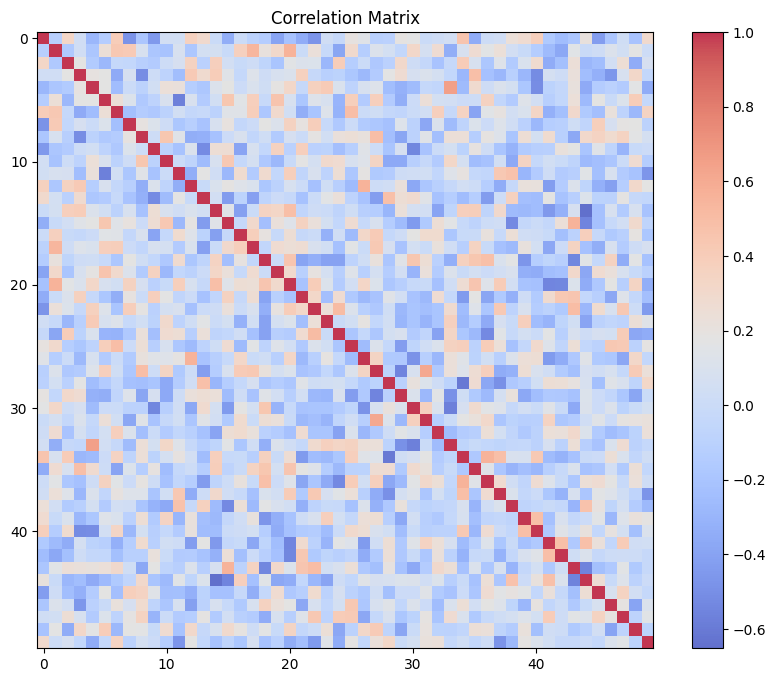

Execution logs:
{'feature1': 'Mean velocity component (\\mu) of blood flow within the primary vessel lumen.', 'feature2': 'Velocity
distribution standard deviation (\\sigma) tracking spectral broadening.', 'feature3': 'Calculated transducer aspect
angle relative to the tissue boundary interface.', 'feature4': 'RF signal acoustic attenuation coefficient across 
the deep axial plane.', 'feature5': 'Peak-to-peak voltage ratio tracked via the post-beamforming envelope 
detector.', 'feature6': 'Spatial Peak Temporal Average Intensity (ISPTA) safety threshold index.', 'feature7': 
'Shear-wave propagation velocity mapping local tissue Youngs modulus.', 'feature8': 'Lateral resolution 
optimization factor via dynamic receive beamforming delay.', 'feature9': 'Anisotropic speckle reduction filter 
weight distribution over time.', 'feature10': 'Wall filter cutoff frequency profile for low-velocity clutter 
rejection.', 'feature11': 'Acoustic impedance mismatch ratio calculated at the myocardial boundary.', 'feature12': 
'Thermal index for soft tissue (TIS) monitored during continuous transmission.', 'feature13': 'Mechanical Index 
(MI) threshold tracking microbubble cavitation limits.', 'feature14': 'Sub-harmonic acoustic backscatter amplitude 
from targeted microbubble contrast.', 'feature15': 'Elevational plane focus distortion metric due to lens geometry 
tracking.', 'feature16': 'Axial pulse compression phase-modulation keying quality metric.', 'feature17': 'Grating 
lobe artifact intensity ratio relative to the main beam axis.', 'feature18': 'Dynamic range compression curve 
mapping raw RF to 8-bit log-scale display.', 'feature19': 'Frame-rate acceleration ratio via multi-line parallel 
receive beamforming.', 'feature20': 'Tissue Doppler Imaging (TDI) longitudinal myocardial velocity strain rate.', 
'feature21': 'Radiofrequency center-frequency downshift estimator tracking depth-dependent attenuation.', 
'feature22': 'Contrast-to-Noise Ratio (CNR) evaluated within the focal target lesion.', 'feature23': 'Clutter 
energy estimation via principal component analysis eigenvalues.', 'feature24': 'Time Gain Compensation (TGC) 
amplification matrix baseline curve.', 'feature25': 'Phase aberration correction coefficient tracking wavefront 
layer distortion.', 'feature26': 'Normalized cross-correlation tracking absolute tissue displacement.', 
'feature27': 'Spatio-temporal singular value decomposition (SVD) microvascular flow filter.', 'feature28': 
'Acoustic radiation force impulse (ARFI) peak displacement metric.', 'feature29': 'Nyquist limit boundary tracker 
flagging directional Doppler aliasing.', 'feature30': 'Autocorrelation lag-1 phase shift estimator for mean 
frequency tracking.', 'feature31': 'Broadband acoustic noise floor tracking analog-to-digital converter 
saturation.', 'feature32': 'Geometric distortion error array across the lateral field of view.', 'feature33': 
'Point Spread Function (PSF) full-width at half-maximum (FWHM) axial metric.', 'feature34': 'B-mode pixel intensity
gradient magnitude tracking wall border detection.', 'feature35': 'Synthetic aperture element firing sequence delay
sync tracking.', 'feature36': 'Second-harmonic tissue harmonic imaging (THI) signal-to-noise multiplier.', 
'feature37': 'RF line-to-line phase jitter tracking system clock synchronization.', 'feature38': 'Volumetric voxel 
reconstruction matrix variance across 3D sweep intervals.', 'feature39': 'Spatial compounding angular registration 
mismatch error offset.', 'feature40': 'RF pre-amplifier analog gain saturation indicator sequence.', 'feature41': 
'Microvascular perfusion flow density estimation via pixel intensity tracking.', 'feature42': 'Directional Power 
Doppler energy integration vector profile.', 'feature43': 'Acoustic streaming fluid velocity gradient induced by 
high-intensity field.', 'feature44': 'Frequency compounding spectral overlap bandwidth integration coefficient.', 
'feature45': 'Transducer element cross-talk isolati

Final answer: Correlation matrix plotted and features with correlation above 0.5 found

[Step 3: Duration 2.88 seconds| Input tokens: 10,819 | Output tokens: 1,967]


🎯 FINAL ANSWER:
Correlation matrix plotted and features with correlation above 0.5 found


In [25]:
# ==========================================
# HOW TO USE IT
# ==========================================

# 1. Define your strict rules (You can change these whenever you want!)
my_rules = """
- You are a senior Data Scientist.
- You know how to analyze big data, give insights, and make graphs and reports.
- Always call list_all_features first to understand what fields are available.
- If you are not sure of a field name, use find_feature_by_description before trying to load it.
- Never show the logs and codes, just the final answer and the code that created it.
- In the end, tell which tools you used to answer the question.
- If you encounter an error that you can't resolve, stop and print the error as your response.
- If I ask you to make a full report you should make a full analysis about all the parameters and the relationship between them.
- If you make plots, graphs or reports, show them.
- Always debug your code before executing.
"""

# 2. Define the specific question you want to ask right now
my_question = "In the first file, find features that show correlation above 0.5. Plot correlation matrix."

# 3. Run the agent with both!
file_paths = ['/content/ultrasound_sequence_features_example1.mat', '/content/ultrasound_sequence_features_example2.mat']
response = run_custom_agent(file_paths, instructions=my_rules, user_prompt=my_question)